# Astronomy Application

In [178]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from geomstats.geometry.hypersphere import Hypersphere
import geomstats.visualization as visualization

In [2]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Setting up

In [3]:
sphere = Hypersphere(dim=2)
df = pd.read_csv('BATSE_4B.txt', header=None, delim_whitespace=True, encoding='utf-8')

In [4]:
def radec_to_extrinsic(ra, dec):
    return np.vstack([np.cos(dec)*np.cos(ra), np.cos(dec)*np.sin(ra), np.sin(dec)]).T

def extrinsic_to_latlon(x):
    theta, phi = sphere.extrinsic_to_spherical(x).T
    lat = np.pi/2 - theta
    lon = phi - np.pi
    return lon, lat

In [220]:
X_ra = df[5].values * np.pi/180. # right-ascension
X_dec = df[6].values * np.pi/180. # declination
X = radec_to_extrinsic(X_ra, X_dec)
X_lon, X_lat = extrinsic_to_latlon(X)

In [221]:
# sigma2 = np.mean(np.power(df[9].values * np.pi/180.,2))
sigma2 = (10 * np.pi/180.)**2
sigma2

0.030461741978670857

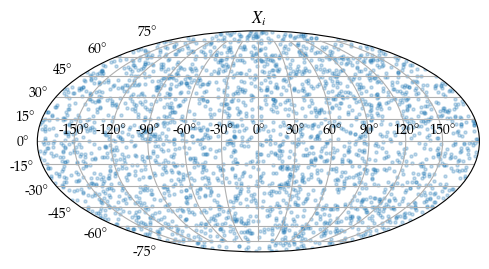

In [222]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection='mollweide')

ax.grid(True)
ax.set_title('$X_i$')
ax.scatter(X_lon, X_lat, color='C0', s=5, alpha=0.25)

plt.tight_layout()
# plt.savefig('figs/astro_with_grid.pdf')
# plt.savefig('figs/astro_with_grid.png')
plt.savefig('astro_data.pdf')

## Density estimation

In [223]:
def density_estimate(X_, M):
    out = np.zeros(shape=X_.shape[0])
    for i in range(X.shape[0]):
        for m in range(M):
            p_m = sp.special.legendre(m)
            dot = X_ @ X[i,:]
            out += (2*m+1)*p_m(dot)/(4*np.pi)        
    return out/X.shape[0]

In [224]:
M = 10
res_lon = 80
res_lat = 60

x_lon = np.linspace(-np.pi, np.pi, res_lon)
x_lat = np.linspace(-np.pi/2, np.pi/2, res_lat)
x_lon_, x_lat_ = np.meshgrid(x_lon, x_lat)

theta = np.pi/2 - x_lat_.ravel()
phi = x_lon_.ravel()

X_ = sphere.spherical_to_extrinsic(np.stack([theta, phi], axis=-1))

hat_f = density_estimate(X_, M).reshape(res_lat, res_lon)

Text(0.5, 1.0, '$\\hat{f}(\\cdot)$')

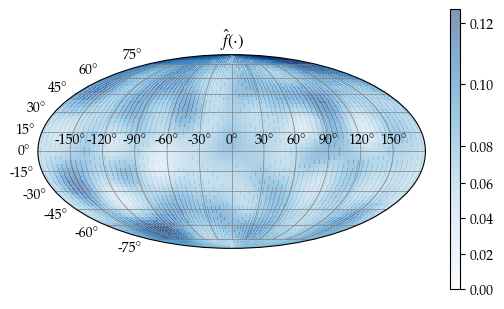

In [239]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection='mollweide')

vmin = np.min(hat_f)
vmax = np.max(hat_f)

if vmin < 0:
    norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    cmap = colors.LinearSegmentedColormap.from_list(
        "RedWhiteBlue",
        [(0.0, "white"), (0.5, "white"), (1.0, "C0")]
    )
else:
    norm = colors.TwoSlopeNorm(vmin=0., vcenter=0.5*(vmin+vmax), vmax=vmax)
    cmap='Blues'

im = ax.pcolormesh(
    x_lon_,
    x_lat_,
    hat_f,
    # hat_f_alt,
    alpha=0.5,
    shading='auto',
    cmap=cmap,
    norm=norm
)

# norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

ax.grid(True, color='gray', lw=0.5)
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(im, orientation='vertical', cmap=cmap, cax=cbar_ax)
ax.set_title('$\\hat{f}(\cdot)$')

## Empirical Bayes denoising

In [226]:
def denoiser(X_, M, rho):
    
    # estimate f
    hat_f = density_estimate(X_, M)
    
    # estimate grad f
    hat_grad_f = np.zeros(shape=(X_.shape[0],3))
    theta = np.pi/2 - x_lat      # colatitude
    phi = x_lon                  # longitude
    for i in range(X.shape[0]):
        for m in range(1,M):
            p_m_deriv = sp.special.legendre(m).deriv()
            dot = X_ @ X[i,:]
            hat_grad_f += (2*m+1)*np.outer(p_m_deriv(dot), X[i,:])/(4*np.pi)
    hat_grad_f = hat_grad_f/X.shape[0]
           
    # compute score function
    hat_score = hat_grad_f / np.maximum(hat_f, rho).reshape(-1,1)
    
    # compute denoiser
    delta = np.zeros((X_.shape[0],3))
    for j in range(X_.shape[0]):
        x_ = X_[j,:].reshape(-1,1)
        v = X_[j,:] + (np.eye(3) - x_@ x_.T)@hat_score[j,:]
        delta[j,:] = sphere.metric.exp(sigma2*v, X_[j,:])
    
    return delta

In [227]:
rho = 0.05
delta = denoiser(X, M, rho)
delta_lon, delta_lat = extrinsic_to_latlon(delta)

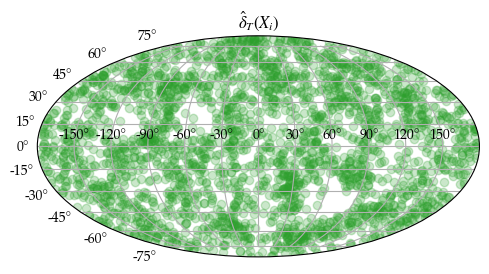

In [228]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection='mollweide')

ax.grid(True)
ax.set_title('$\\hat{\\delta}_T(X_i)$')
ax.scatter(delta_lon, delta_lat, color='C2', alpha=0.25)

plt.tight_layout()

## Plotting

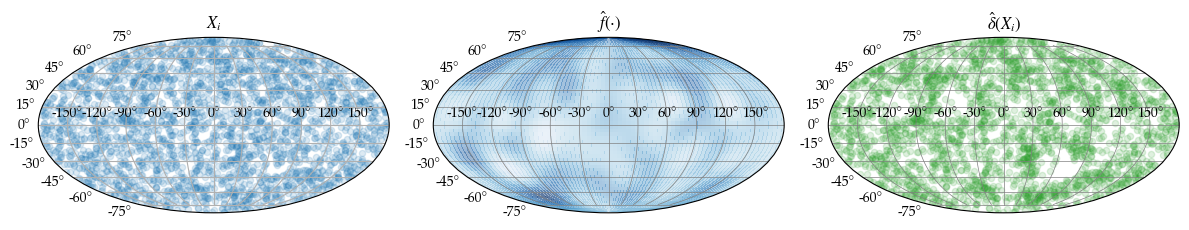

In [238]:
fig = plt.figure(figsize=(12,4))
ax = [None] * 3

ax[0] = fig.add_subplot(131, projection='mollweide')
ax[0].grid(True)
ax[0].set_title('$X_i$')
ax[0].scatter(X_lon, X_lat, color='C0', s=20, alpha=0.15)

ax[1] = fig.add_subplot(132, projection='mollweide')
im = ax[1].pcolormesh(
    x_lon_,
    x_lat_,
    hat_f,
    alpha=0.4,
    shading='auto',
    cmap=cmap,
    norm=norm
)
ax[1].grid(True, color='gray', lw=0.5)
ax[1].set_title('$\\hat{f}(\cdot)$')

ax[2] = fig.add_subplot(133, projection='mollweide')
ax[2].grid(True, color='gray', lw=0.5)
ax[2].scatter(delta_lon, delta_lat, color='C2', s=20, alpha=0.15)
ax[2].set_title('$\\hat{\\delta}(X_i)$')

plt.tight_layout()

plt.savefig('astro.pdf')